## 4장 1강: 파이토치 기초 및 심층 신경망

### 6. 파이토치 기반 패션 이미지 다층 모델 실습
#### 6.1 데이터 준비 및 전처리
실습에 필요한 도구 불러오기 및 설정

In [1]:
import torch
from torchvision    import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

print(f"현재 사용 중인 연산 디바이스: {device}")

현재 사용 중인 연산 디바이스: cuda


Fashion MNIST 데이터 불러오기

In [2]:
# Fashion MNIST 28 X 28 (0~255)
# 60,000 -> 훈련 데이터는 50,000 장, 검증 (100,000)

# 훈련 데이터 셋
raw_train_data = datasets.FashionMNIST(
    root = 'data', train=True, download=True, transform=ToTensor()
)

# 테스트 데이터 셋
test_data = datasets.FashionMNIST(
    root='data', train=False, download=True, transform=ToTensor()
)

In [3]:
# 검증 데이터 셋 분리
train_size = 50000
val_size = 10000

train_data, val_data = random_split(
    raw_train_data, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print('훈련 세트:',len(train_data))
print('검증 세트:',len(val_data))
print('테스트 세트:',len(test_data))

훈련 세트: 50000
검증 세트: 10000
테스트 세트: 10000


In [4]:
# 데이터 세트별 DataLoader 생성
# batch_size -> ㅇ포크에서 전 데이터셋을 32개의 배치로 분할 -> 미니배치 경사하강법
train_loader = DataLoader(train_data,batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

### 6.2 모델 설계

다층 퍼셉트론(MLP) 모델 클래스 정의

In [5]:
import torch.nn as nn
import torch.optim as optim

class AdvancedFashionClassfier(nn.Module):

    # 사용할 층(layer)를 정의
    def __init__(self):
        super().__init__()

        # (28,28) -> 특성은 1차원으로 변경 (784,)
        ## nn.Flatten() -> 2차원 텐서 -> 1차원 텐서 - 입력층
        self.flatten = nn.Flatten()

        # 은닉층 (784 -> 128)
        self.input_layer = nn.Linear(784, 128)

        # 활성화 함수(ReLU)
        self.relu = nn.ReLU()

        # Dropout - 0~1, 0.1~0.5
        self.dropout = nn.Dropout(p=0.2)

        # 출력층 128 -> 10
        self.output_layer = nn.Linear(128,10)

    # 순전판(Feed Forward)
    def forward(self,x):
            out = self.flatten(x) # 28 x 27 -> 784 # 입력층 처리
            out = self.input_layer(out) # 784 -> 128 # 은닉층 처리
            out = self.relu(out) # 활성화 함수 통과 (선형적 -> 비선형적)
            out = self.dropout(out) # 훈련시에만 피요, 과대적합 방지(128,)
            out = self.output_layer(out) # 출력층 128 -> 10

            return out

모델 인스턴스 생성 및 연산 디바이스(GPU/MPS/CPU)로 할당

In [6]:
model = AdvancedFashionClassfier().to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"학습 가능한 총 모델 파라미터 갯수: {total_params:,}개")

학습 가능한 총 모델 파라미터 갯수: 101,770개


손실 함수 및 옵티마이저 정의


In [7]:
# 손실 함수
criterion = nn.CrossEntropyLoss()

# 옵티마이저
optimizer = optim.Adam(model.parameters(), lr=0.005)

### 6.3 조기 종료 학습 및 검증 루프

In [8]:
epochs = 20 # 최대 에포크
patience = 3 # 검증 로스가 더이상 떨어지지 않는 횟수, 3회 이상이면 학습 종료(조기종료)
patience_count = 0 #
best_val_loss = float('inf')

train_losses = []
val_losses = []

for epoch in range(epochs):
    running_loss = 0.0 #한 에포크 (각 배치의 모든 손실)
    model.train() # 학습 모드 (학습에 필요한 것들 활성 - 예) Dropout)

    for images, labels in train_loader: #미니배치(32개씩)
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # 이전 그래디언트(기울기)를 초기화

        #순방향 예측
        outputs = model(images)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 오차 역전파 수행 - 그래디언트(기울기)
        loss.backward()

        # 옵티마이저를 통한 가중치 업데이트
        optimizer.step()
        running_loss += loss.item() # 배치마다의 로스를 기록(1에포크)

    epoch_loss = running_loss / len(train_loader) # 1에포크 로스 (배치 로스의 평균)
    train_losses.append(epoch_loss)

    # 검증 모드
    model.eval() #평가시에는 학습시에만 필요한 부분이 배제, dropout 배제
    val_loss = 0.0

    with torch.no_grad(): # 검증시에는 그래디언트를 구하지 않는다. 학습 관련 연산을 하지 않음.
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            # 검증 예측 (순전파)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | 훈련 loss: {epoch_loss:.4f} | 검증 loss: {val_loss:.4f}")

    # 조기 종료
    if epoch_val_loss < best_val_loss:
        # 기존 검증 로스보다 개선이 되었다!
        best_val_loss = epoch_val_loss
        patience_count = 0

        # 손실이 개선된 모델을 저장
        torch.save(model.state_dict(), "best_fashion_model.pth")
    else: # 기존 검증 로스보다 개선이 안되었다
        patience_count += 1
        print(f"== 검증 손실 미개선: {patience_count}/{patience} ==")

        # patience 한계를 초과하면 학습을 중단(조기종료)
        if patience_count >= patience:
            print(f"조기 종료:{epoch+1}에포크에서 학습 종료...")
            break

Epoch 1/20 | 훈련 loss: 0.5668 | 검증 loss: 145.2690
Epoch 2/20 | 훈련 loss: 0.4768 | 검증 loss: 136.3339
Epoch 3/20 | 훈련 loss: 0.4464 | 검증 loss: 126.4008
Epoch 4/20 | 훈련 loss: 0.4296 | 검증 loss: 131.1222
== 검증 손실 미개선: 1/3 ==
Epoch 5/20 | 훈련 loss: 0.4182 | 검증 loss: 122.5156
Epoch 6/20 | 훈련 loss: 0.4096 | 검증 loss: 129.0158
== 검증 손실 미개선: 1/3 ==
Epoch 7/20 | 훈련 loss: 0.3953 | 검증 loss: 120.8220
Epoch 8/20 | 훈련 loss: 0.3919 | 검증 loss: 121.8371
== 검증 손실 미개선: 1/3 ==
Epoch 9/20 | 훈련 loss: 0.3819 | 검증 loss: 118.0402
Epoch 10/20 | 훈련 loss: 0.3807 | 검증 loss: 125.7670
== 검증 손실 미개선: 1/3 ==
Epoch 11/20 | 훈련 loss: 0.3733 | 검증 loss: 125.5329
== 검증 손실 미개선: 2/3 ==
Epoch 12/20 | 훈련 loss: 0.3709 | 검증 loss: 131.0045
== 검증 손실 미개선: 3/3 ==
조기 종료:12에포크에서 학습 종료...


### 6.4 최종 테스트셋 기반 정확도 측정 및 시각화

In [9]:
# 가장 좋은 가중치지의 모델을 불러오기
model.load_state_dict(torch.load('best_fashion_model.pth'))
model.to(device)

# 테스트 셋으로 평가
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        print("predicted:", predicted)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total * 100
print(f"테스트 세트 정확도: {test_accuracy:.4f}")

predicted: tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4, 1, 2, 2, 8, 0, 2, 5, 7, 7,
        1, 2, 6, 0, 9, 3, 8, 8], device='cuda:0')
predicted: tensor([3, 3, 8, 0, 7, 5, 7, 9, 0, 1, 6, 7, 6, 7, 2, 1, 2, 2, 4, 2, 5, 8, 2, 2,
        8, 4, 8, 0, 7, 7, 8, 5], device='cuda:0')
predicted: tensor([1, 1, 6, 3, 7, 8, 7, 0, 2, 6, 4, 3, 1, 2, 8, 4, 1, 8, 5, 9, 5, 0, 3, 2,
        0, 2, 5, 3, 6, 7, 1, 8], device='cuda:0')
predicted: tensor([0, 1, 6, 2, 3, 6, 7, 6, 7, 8, 5, 7, 9, 4, 2, 5, 7, 0, 5, 2, 8, 6, 7, 8,
        0, 0, 9, 9, 3, 0, 8, 2], device='cuda:0')
predicted: tensor([1, 5, 4, 1, 9, 1, 8, 6, 6, 1, 2, 5, 1, 6, 0, 0, 1, 6, 1, 3, 2, 2, 3, 2,
        1, 3, 5, 0, 4, 7, 9, 3], device='cuda:0')
predicted: tensor([7, 2, 3, 9, 0, 9, 4, 7, 4, 2, 6, 5, 2, 1, 2, 1, 3, 0, 9, 1, 0, 9, 3, 8,
        7, 9, 9, 4, 4, 7, 1, 2], device='cuda:0')
predicted: tensor([3, 2, 3, 2, 8, 3, 6, 1, 1, 0, 2, 9, 2, 4, 0, 7, 9, 8, 4, 1, 8, 4, 1, 3,
        1, 6, 7, 4, 8, 5, 3, 0], device='cuda:0')
predicted: te


=== 최종 테스트셋(실전 성능) 평가 시작 ===
최종 테스트 데이터셋 정확도(Test Accuracy): 86.17%


c:\Users\IAM87\Documents\ax_study\04_MACHINE_LEARNING\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\IAM87\Documents\ax_study\04_MACHINE_LEARNING\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\IAM87\Documents\ax_study\04_MACHINE_LEARNING\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\IAM87\Documents\ax_study\04_MACHINE_LEARNING\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\IAM87\Documents\ax_study\04_MACHINE_LEARNING

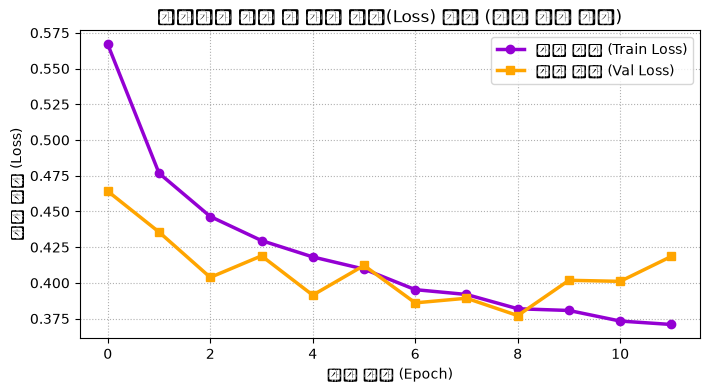

In [10]:
# 학습 과정 중 가장 성적이 좋았던 가중치 파일(pth) 복원
model.load_state_dict(torch.load("best_fashion_model.pth"))
model.to(device)

# 테스트셋 기반 최종 실전 정확도(Accuracy) 측정
model.eval()  # 추론 및 평가 모드로 고정
correct = 0
total = 0

print("\n=== 최종 테스트셋(실전 성능) 평가 시작 ===")
with torch.no_grad():  # 평가 단계이므로 미분 계산 비활성화
    for images, labels in test_loader:
        # 테스트 데이터셋 역시 연산 전 가속기로 이동시킵니다.
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        # 각 행(인스턴스)별로 10개 카테고리 중 가장 높은 점수를 받은 인덱스 추출
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)                       # 전체 데이터 개수 누적
        correct += (predicted == labels).sum().item()  # 정답을 맞춘 개수 누적

test_accuracy = 100 * correct / total
print(f"최종 테스트 데이터셋 정확도(Test Accuracy): {test_accuracy:.2f}%")

# 3. 에포크별 훈련 및 검증 손실 곡선 시각화
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker='o', color='darkviolet', linewidth=2.5, label='훈련 손실 (Train Loss)')
plt.plot(val_losses, marker='s', color='orange', linewidth=2.5, label='검증 손실 (Val Loss)')
plt.title("에포크별 훈련 및 검증 손실(Loss) 추이 (조기 종료 적용)")
plt.xlabel("학습 횟수 (Epoch)")
plt.ylabel("손실 크기 (Loss)")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()
